In [3]:
%pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 23.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 41.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21/21 [tensorflow]1 [tensorflow]-py]

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


I0000 00:00:1789672298.072426   12091 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789672298.153056   12091 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789672300.692814   12091 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/codespace/.python/current/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1789672305.985348   12091 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
First 10 predictions:
[1.0] => 1.0063 (expected 1.0000)
[2.0] => 1.0926 (expected 1.1041)
[3.0] => 1.1696 (expected 1.1699)
[4.0] => 1.2189 (expected 1.2190)
[5.0] => 1.2603 (expected 1.2585)
[6.0] => 1.2926 (expected 1.2917)
[7.0] => 1.3336 (expected 1.3205)
[8.0] => 1.3513 (expected 1.3459)
[9.0] => 1.3682 (expected 1.3687)
[10.0] => 1.3851 (expected 1.3895)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


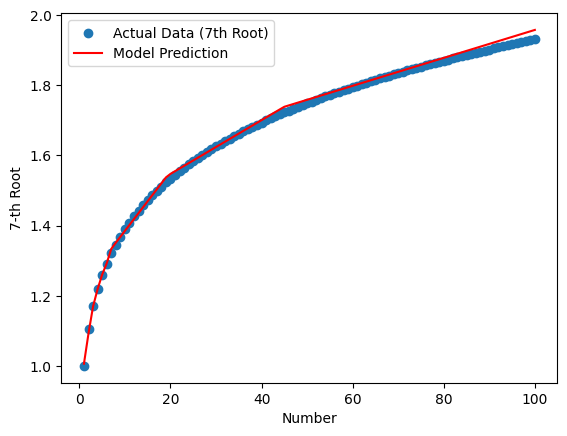

In [1]:
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate dataset for integers between 1 and 100
X = np.arange(1, 101).reshape(-1, 1).astype(float)
y = X ** (1/7.0)

# 2. Define keras model
model = Sequential()
model.add(Dense(16, input_dim=1, activation='relu')) # Increased neurons to 16 for better fitting
model.add(Dense(16, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

# 3. Compile the keras model
opt = optimizers.Adam(learning_rate=0.001)
mse = tf.keras.losses.MeanSquaredError(reduction=tf.keras.losses.Reduction.SUM)
model.compile(loss=mse, optimizer=opt)

# 4. Fit the keras model on the dataset
model.fit(X, y, epochs=2000, batch_size=10, verbose=0)

# 5. Make predictions and summarize the first 10 cases
predictions = model.predict(X)

print("First 10 predictions:")
for i in range(10):
    print('[%.1f] => %.4f (expected %.4f)' % (X[i][0], predictions[i][0], y[i][0]))

# 6. Plot the results
number_grid = np.linspace(1, 100, 100)
plt.scatter(X, y, label='Actual Data (7th Root)')
plt.plot(number_grid, model.predict(np.expand_dims(number_grid, axis=1)), color='red', label='Model Prediction')
plt.xlabel('Number')
plt.ylabel('7-th Root')
plt.legend()
plt.show()